In [1]:
import pandas as pd
import numpy as np
import tqdm
import random
import matplotlib.pyplot as plt

In [2]:
# load only clean paired testing sessions from the list that David was using
old = pd.read_csv("only_PairedTesting_filtered.csv")
df = pd.DataFrame()
df['video'] = old['vid']
df['session'] = old['session']
df['color pair'] = old['color pair']

In [ ]:
# calculate the "normal" success rate from what's reported in the file
norm = calc_norm_succ(df)
# and then recalcuate the "real" success rate from our definition
real = calc_real_succ(df)
# calculate the shuffled success rate 
shuf1 = calc_shuf_succ(df)

In [ ]:
# example of 5 different shuffles

# shuf2 = calc_shuf_succ(df)
# shuf3 = calc_shuf_succ(df)
# shuf4 = calc_shuf_succ(df)
# shuf5 = calc_shuf_succ(df)

# x = plt.boxplot([real, shuf1, shuf2, shuf3, shuf4, shuf5], positions=[1, 2, 3, 4, 5, 6], medianprops=dict(color='black', linewidth=2))

# # Add individual points
# for i, data in enumerate([real, shuf1, shuf2, shuf3, shuf4, shuf5], start=1):
#     # jitter the x-positions slightly
#     x_jitter = np.random.normal(i, 0.05, size=len(data))
#     plt.scatter(x_jitter, data, alpha=0.6, s=20)
    
# plt.xticks([1, 2, 3, 4, 5, 6], ['real', 'shuf1', 'shuf2', 'shuf3', 'shuf4', 'shuf5'])
# plt.ylabel('percent success')
# plt.show()


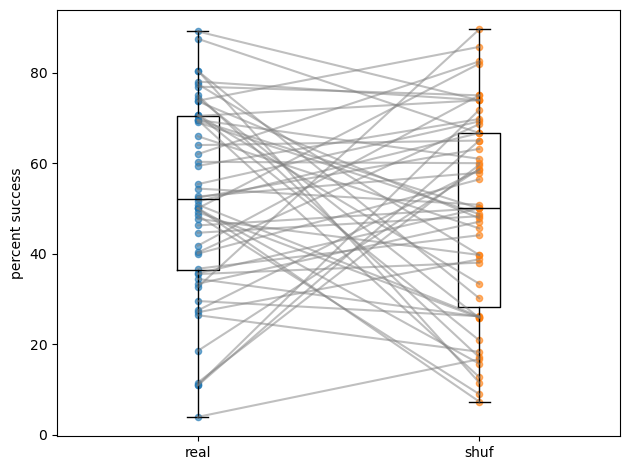

In [227]:
# connected shuffles for paired testing sessions

# plt.figure(figsize=(6, 5))

# --- Boxplot ---
plt.boxplot(
    [real, shuf],
    positions=[1, 2],
    medianprops=dict(color='black'),
)

# --- Paired points + connecting lines ---
for i in range(len(shuf1)):
    # plot the two points
    plt.scatter(1, real[i], alpha=0.6, s=20, color='tab:blue')
    plt.scatter(2, shuf1[i], alpha=0.6, s=20, color='tab:orange')
    
    # connect them with a line
    plt.plot([1, 2], [real[i], shuf1[i]], color='gray', alpha=0.5)

plt.xticks([1, 2], ["real", "shuf"])
plt.xlim(0.5, 2.5)
plt.ylabel("percent success")

plt.tight_layout()
plt.show()


In [228]:
# NUMBER OF SHUFFLES HERE
reps = 2

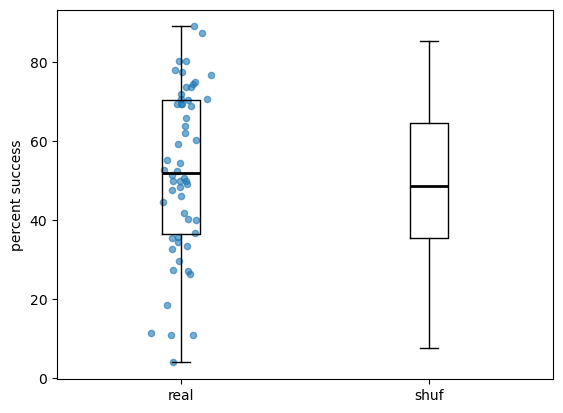

In [230]:
# repeated shuffles for paired testing sessions

shuf_succ = []
for j in range(reps):
    shuf_succ = np.concatenate([shuf_succ, calc_shuf_succ(df)])

x = plt.boxplot([real, shuf_succ], positions=[1, 2], medianprops=dict(color='black', linewidth=2))

# Add individual points
for i, data in enumerate([real], start=1):
    # jitter the x-positions slightly
    x_jitter = np.random.normal(i, 0.05, size=len(data))
    plt.scatter(x_jitter, data, alpha=0.6, s=20)
    
plt.xticks([1, 2], ['real', 'shuf'])
plt.ylabel('percent success')
plt.show()

In [72]:
# fixing all df

# for index, row in all_df.iterrows():
#     use = 'unuseable'
#     if row['error'] < 0.2 and row['lever']:
#         use = 'normal'
#         if row['visual'] != 'transparent' or row['familiar'] != 'familiar' or (row['vehicle'] == 'CNO' or row['vehicle'] == 'DCZ' or row['vehicle'] == 'SAL'):
#             use = 'control'
#     all_df.at[index, 'useable'] = use

In [24]:
# load all of the cooperation sessions
# all_df = pd.read_csv('all_coop_uncorrected.csv')
# all_df.to_csv('all_coop_uncorrected.csv', index=False)
# all_df

In [ ]:
# DO COMPARISON FOR DIFFERENT VISUAL TYPES...! 

In [11]:
import time
start = time.time()

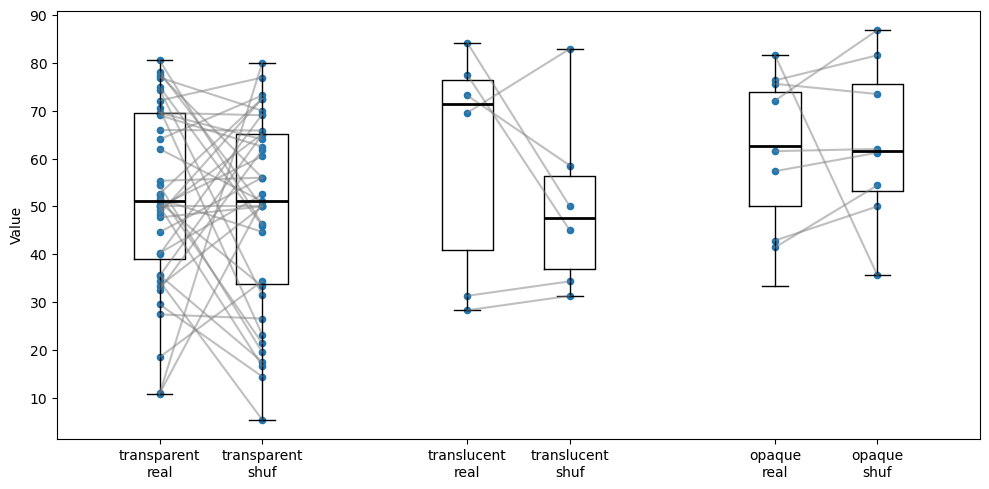

In [246]:
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & ((all_df['useable'] == 'normal') | (all_df['useable'] == 'control'))]
vises = []
norm_succ = []
real_succ = []
shuf_succ = np.zeros((len(np.unique(test['visual'])), reps))

pairs = []

for i, vis in enumerate(sorted(np.unique(test['visual']), reverse=True)):
    if vis == 'transparent': 
        test_thresh = test[(test['visual'] == 'transparent') & (test['useable'] == 'normal') & (test['cohort'] == 'KL')]
    else:
        test_thresh = test[test['visual'] == vis]
    real = calc_real_succ(test_thresh)
    shuf = calc_shuf_succ(test_thresh)
    pairs.append((real, shuf, vis))
    # vises.append(vis)
    # norm_succ.append(calc_norm_succ(test_thresh))
    # real_succ.append(calc_real_succ(test_thresh))
    # for j in range(reps):
    #     shuf_succ[i, j] = calc_shuf_succ(test_thresh)
    # print(vis, calc_norm_succ(test_thresh), calc_real_succ(test_thresh), calc_shuf_succ(test_thresh))


# Organize data
# pairs = [
#     (real1, shuf1, "Cond 1"),
#     (real2, shuf2, "Cond 2"),
#     (real3, shuf3, "Cond 3")
# ]

plt.figure(figsize=(10, 5))

positions = []   # x-locations for boxplots
plot_data = []   # data passed to plt.boxplot
labels = []      # x-axis labels

# Build boxplots: two per condition
pos = 1
for real, shuf, name in pairs:
    plot_data.append(real)
    plot_data.append(shuf)
    positions.extend([pos, pos + 1])
    labels.extend([f"{name}\nreal", f"{name}\nshuf"])
    pos += 3   # leave a small gap between conditions

# --- Boxplot ---
plt.boxplot(
    plot_data,
    positions=positions,
    medianprops=dict(color='black', linewidth=2),
)

# --- Paired lines for each condition ---
for idx, (real, shuf, name) in enumerate(pairs):
    x_real = positions[idx*2]       # the real x-position
    x_shuf = positions[idx*2 + 1]   # the shuf x-position
    
    for i in range(len(shuf)):
        plt.scatter([x_real, x_shuf], [real[i], shuf[i]], color='tab:blue', s=20)
        plt.plot([x_real, x_shuf], [real[i], shuf[i]], color='gray', alpha=0.5)

plt.xticks(positions, labels, rotation=0)
plt.xlim(min(positions)-1, max(positions)+1)
plt.ylabel("Value")
plt.tight_layout()
plt.show()


In [12]:
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & ((all_df['useable'] == 'normal') | (all_df['useable'] == 'control'))]
vises = []
norm_succ = []
real_succ = []
shuf_succ = np.zeros((len(np.unique(test['visual'])), reps))

for i, vis in enumerate(sorted(np.unique(test['visual']), reverse=True)):
    if vis == 'transparent': 
        test_thresh = test[(test['visual'] == 'transparent') & (test['useable'] == 'normal') & (test['cohort'] == 'KL')]
    else:
        test_thresh = test[test['visual'] == vis]
    vises.append(vis)
    norm_succ.append(calc_norm_succ(test_thresh))
    real_succ.append(calc_real_succ(test_thresh))
    for j in range(reps):
        shuf_succ[i, j] = calc_shuf_succ(test_thresh)
    # print(vis, calc_norm_succ(test_thresh), calc_real_succ(test_thresh), calc_shuf_succ(test_thresh))


In [ ]:
# plt.plot(threshes, norm_succ, label='norm')
plt.plot([0, 1, 2], real_succ, label='real')
mean = np.mean(shuf_succ, axis=1)
std = np.std(shuf_succ, axis=1)
plt.plot([0, 1, 2], mean, label='shuff')
plt.fill_between([0, 1, 2], mean - std, mean + std,
                        color='k', alpha=0.2)
plt.legend()
plt.title(vises)
# plt.gca().invert_xaxis()
plt.savefig("visual.png")

In [ ]:
# DO COMPARISON FOR DIFFERENT Familarity TYPES...! 

In [249]:
np.unique(all_df['familiar'])

array(['familiar', 'unfamiliar', 'unsure'], dtype=object)

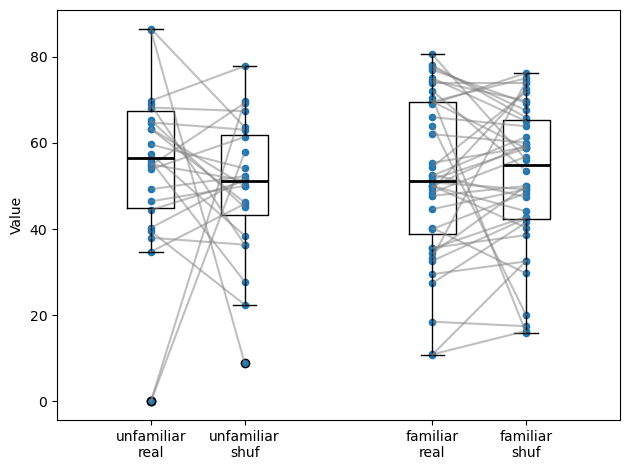

In [252]:
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & ((all_df['useable'] == 'normal') | (all_df['useable'] == 'control'))]
vises = []
norm_succ = []
real_succ = []
shuf_succ = np.zeros((len(np.unique(test['familiar'])), reps))

pairs = []

for i, fam in enumerate(sorted(np.unique(test['familiar']), reverse=True)):
    if fam == 'familiar': 
        test_thresh = test[(test['familiar'] == 'familiar') & (test['useable'] == 'normal') & (test['cohort'] == 'KL')]
    else:
        test_thresh = test[test['familiar'] == fam]
    real = calc_real_succ(test_thresh)
    shuf = calc_shuf_succ(test_thresh)
    pairs.append((real, shuf, fam))
    # vises.append(vis)
    # norm_succ.append(calc_norm_succ(test_thresh))
    # real_succ.append(calc_real_succ(test_thresh))
    # for j in range(reps):
    #     shuf_succ[i, j] = calc_shuf_succ(test_thresh)
    # print(vis, calc_norm_succ(test_thresh), calc_real_succ(test_thresh), calc_shuf_succ(test_thresh))


# Organize data
# pairs = [
#     (real1, shuf1, "Cond 1"),
#     (real2, shuf2, "Cond 2"),
#     (real3, shuf3, "Cond 3")
# ]

# plt.figure(figsize=(10, 5))

positions = []   # x-locations for boxplots
plot_data = []   # data passed to plt.boxplot
labels = []      # x-axis labels

# Build boxplots: two per condition
pos = 1
for real, shuf, name in pairs:
    plot_data.append(real)
    plot_data.append(shuf)
    positions.extend([pos, pos + 1])
    labels.extend([f"{name}\nreal", f"{name}\nshuf"])
    pos += 3   # leave a small gap between conditions

# --- Boxplot ---
plt.boxplot(
    plot_data,
    positions=positions,
    medianprops=dict(color='black', linewidth=2),
)

# --- Paired lines for each condition ---
for idx, (real, shuf, name) in enumerate(pairs):
    x_real = positions[idx*2]       # the real x-position
    x_shuf = positions[idx*2 + 1]   # the shuf x-position
    
    for i in range(len(shuf)):
        plt.scatter([x_real, x_shuf], [real[i], shuf[i]], color='tab:blue', s=20)
        plt.plot([x_real, x_shuf], [real[i], shuf[i]], color='gray', alpha=0.5)

plt.xticks(positions, labels, rotation=0)
plt.xlim(min(positions)-1, max(positions)+1)
plt.ylabel("Value")
plt.tight_layout()
plt.show()


In [ ]:
# NOW FOR EACH THRESHOLD...!!!

real cannot convert float NaN to integer Training_COOPERATION/041524/Behavioral/processed/lever/041524_COOPTRAIN_LARGEARENA_EB001R-EB003B_Camera1_lever.csv
real cannot convert float NaN to integer Training_COOPERATION/120924/Behavioral/processed/lever/120924_COOPTRAIN_LARGEARENA_NM028R-NM028G_Camera1_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/041424/Behavioral/processed/lever/041424_COOPTRAIN_LARGEARENA_EB031B-EB033Y_Camera3_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/041324/Behavioral/processed/lever/041324_COOPTRAIN_LARGEARENA_EB001R-EB003B_Camera1_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/041224/Behavioral/processed/lever/041224_COOPTRAIN_LARGEARENA_EB011Y-EB015R_Camera3_lever.csv
real cannot convert float NaN to integer Training_COOPERATION/042324/Behavioral/processed/lever/042324_COOPTRAIN_LARGEARENA_EB009B-EB033Y_Camera3_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/04

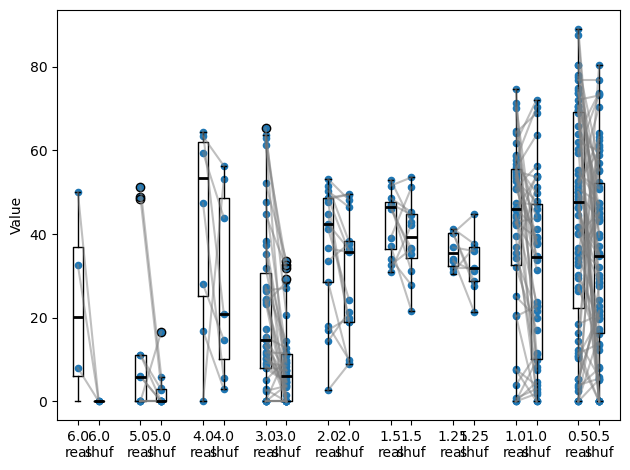

In [57]:
train = all_df[(all_df['dir'] == 'Training_COOPERATION') & (all_df['useable'] == 'normal')]
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & (all_df['useable'] == 'normal')]

pairs = []
for i, thresh in enumerate(sorted(np.unique(train['coop thresh']), reverse=True)):
    train_thresh = train[train['coop thresh'] == thresh]
    real = calc_real_succ(train_thresh, thresh=thresh)
    shuf = calc_shuf_succ(train_thresh, thresh=thresh)
    pairs.append((real, shuf, thresh))
    
i += 1
for thresh in sorted(np.unique(test['coop thresh']), reverse=True):
    test_thresh = test[test['coop thresh'] == thresh]
    real = calc_real_succ(test_thresh, thresh=thresh)
    shuf = calc_shuf_succ(test_thresh, thresh=thresh)
    pairs.append((real, shuf, thresh - 0.5))





# plt.figure(figsize=(10, 5))

positions = []   # x-locations for boxplots
plot_data = []   # data passed to plt.boxplot
labels = []      # x-axis labels

# Build boxplots: two per condition
pos = 1
for real, shuf, name in pairs:
    plot_data.append(real)
    plot_data.append(shuf)
    positions.extend([pos, pos + 1])
    labels.extend([f"{name}\nreal", f"{name}\nshuf"])
    pos += 3   # leave a small gap between conditions

# --- Boxplot ---
plt.boxplot(
    plot_data,
    positions=positions,
    medianprops=dict(color='black', linewidth=2),
)

# --- Paired lines for each condition ---
for idx, (real, shuf, name) in enumerate(pairs):
    x_real = positions[idx*2]       # the real x-position
    x_shuf = positions[idx*2 + 1]   # the shuf x-position
    
    for i in range(len(shuf)):
        plt.scatter([x_real, x_shuf], [real[i], shuf[i]], color='tab:blue', s=20)
        plt.plot([x_real, x_shuf], [real[i], shuf[i]], color='gray', alpha=0.5)

plt.xticks(positions, labels, rotation=0)
plt.xlim(min(positions)-1, max(positions)+1)
plt.ylabel("Value")
plt.tight_layout()
plt.show()


In [260]:
# want each of the threshold for training coop
# and then each threshold for paired testing (which should just be 1)
train = all_df[(all_df['dir'] == 'Training_COOPERATION') & (all_df['useable'] == 'normal')]
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & (all_df['useable'] == 'normal')]

threshes = []
# norm_succ = []
real_succ = []
# shuf_succ = np.zeros((len(np.unique(train['coop thresh'])) + 1, reps))
for i, thresh in enumerate(sorted(np.unique(train['coop thresh']), reverse=True)):
    train_thresh = train[train['coop thresh'] == thresh]
    threshes.append(thresh)
    # norm_succ.append(calc_norm_succ(train_thresh, thresh=thresh))
    real_succ.append(calc_real_succ(train_thresh, thresh=thresh))
    shuf_succ = []
    for j in range(reps):
        # shuf_succ[i, j] = calc_shuf_succ(train_thresh, thresh=thresh)
        shuf_succ = np.concatenate([shuf_succ, calc_shuf_succ(train_thresh, thresh=thresh)])
    # print(thresh, calc_norm_succ(train_thresh), calc_real_succ(train_thresh), calc_shuf_succ(train_thresh))
    
i += 1
for thresh in sorted(np.unique(test['coop thresh']), reverse=True):
    test_thresh = test[test['coop thresh'] == thresh]
    threshes.append(thresh - 0.5)
    norm_succ.append(calc_norm_succ(test_thresh))
    real_succ.append(calc_real_succ(test_thresh))
    for j in range(reps):
        shuf_succ[i, j] = calc_shuf_succ(test_thresh)
        shuf_succ = np.concatenate([shuf_succ, calc_shuf_succ(train_thresh, thresh=thresh)])
    # print(calc_norm_succ(test_thresh), calc_real_succ(test_thresh), calc_shuf_succ(test_thresh))


real cannot convert float NaN to integer Training_COOPERATION/041524/Behavioral/processed/lever/041524_COOPTRAIN_LARGEARENA_EB001R-EB003B_Camera1_lever.csv
real cannot convert float NaN to integer Training_COOPERATION/120924/Behavioral/processed/lever/120924_COOPTRAIN_LARGEARENA_NM028R-NM028G_Camera1_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/041224/Behavioral/processed/lever/041224_COOPTRAIN_LARGEARENA_EB011Y-EB015R_Camera3_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/041424/Behavioral/processed/lever/041424_COOPTRAIN_LARGEARENA_EB031B-EB033Y_Camera3_lever.csv
real cannot convert float NaN to integer Training_COOPERATION/042324/Behavioral/processed/lever/042324_COOPTRAIN_LARGEARENA_EB009B-EB033Y_Camera3_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/042324/Behavioral/processed/lever/042324_COOPTRAIN_LARGEARENA_EB009B-EB033Y_Camera3_lever.csv
shuf cannot convert float NaN to integer Training_COOPERATION/04

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# plt.plot(threshes, norm_succ, label='norm')
plt.plot(threshes, real_succ, label='real')
plt.plot(threshes, real_succ, '.', label='real')
mean = np.mean(shuf_succ, axis=1)
std = np.std(shuf_succ, axis=1)
plt.plot(threshes, mean, label='shuff')
plt.plot(threshes, mean, '.', label='shuff')
plt.fill_between(threshes, mean - std, mean + std,
                        color='k', alpha=0.2)
plt.legend()
plt.gca().invert_xaxis()
plt.savefig("thresh.png")

In [16]:
time.time() - start

27.84704279899597

In [21]:
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & (all_df['useable'] == 'normal')]

In [ ]:
test

In [23]:
for index, row in test.iterrows():
    temp = df[(df['video'] == row['video']) & (df['session'] == row['session'])]
    if len(temp) == 0:
        print(row['video'], row['session'], row['familiar'])
        fam_df = pd.read_excel('/gpfs/radev/pi/saxena/aj764/PairedTestingSessions/' + row['session'] + '/' + row['session'][:12] + '_TrialList.xlsx')
        fam_df = fam_df[(fam_df['SubOneID'] == row['animal id'].split('-')[0]) & (fam_df['SubTwoID'] == row['animal id'].split('-')[1])]
        # print(fam_df['SubTwoFam'])
        # correcting these because they aren't actually familiar
        # all_df.at[index, 'familiar'] = 'unfamiliar'
        # all_df.at[index, 'useable'] = 'control' if all_df.at[index, 'useable'] == 'normal' else all_df.at[index, 'useable']
# THESE ARE NOT REALLY FAMILIAR ACCORDING TO DAVID'S DF AND I TRUST THAT MOST...!

In [13]:
row['animal id']

'EB031B-EB033Y'

In [15]:
fam_df = fam_df[(fam_df['SubOneID'] == row['animal id'].split('-')[0]) & (fam_df['SubTwoID'] == row['animal id'].split('-')[1])]

print(fam_df['SubTwoFam'])

7    UF
Name: SubTwoFam, dtype: object


real cannot convert float NaN to integer PairedTestingSessions/051524_EB015R-011Y_033Y_TimeOut_VEH/Behavioral/processed/lever/051524_Cam3_TrNum12_Coop_EB015R-EB033Y_lever.csv
real cannot convert float NaN to integer PairedTestingSessions/052024_EB031B-001R-EB019Y_TimeOut_VEH_BAD/Behavioral/processed/lever/052024_Cam3_TrNum7_Coop_EB031B-EB019Y_lever.csv
shuf cannot convert float NaN to integer PairedTestingSessions/042624_KL002_TimeOut/Behavioral/processed/lever/042624_Cam3_TrNum5_Coop_KL002B-KL002Y_lever.csv
shuf cannot convert float NaN to integer PairedTestingSessions/051524_EB021R-023B-009B_TimeOut_VEH/Behavioral/processed/lever/051524_Cam4_TrNum7_Coop_EB021R-EB023B_lever.csv


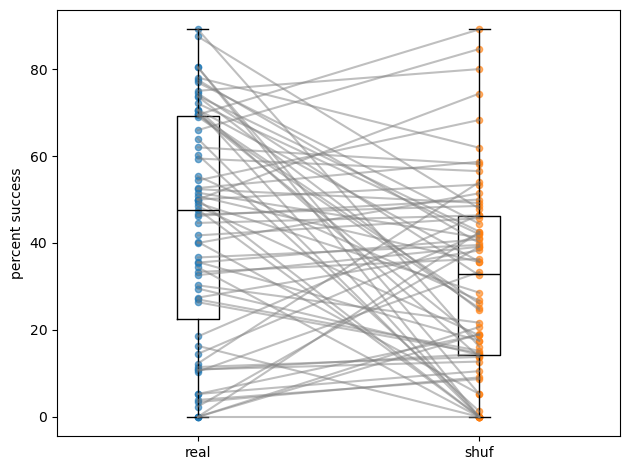

In [75]:
# THIS IS NOT REAL!! BECAUSE THERE ARE SOME IN THE EB COHORT THAT ARE LABELED AS FAMILIAR
# BUT ARE ACTUALLY UNFAMILAR (THIS IS NOTED IN DAVID'S DF SO WE SHOULD GO OFF THAT!!)
test = all_df[(all_df['dir'] == 'PairedTestingSessions')  & (all_df['useable'] == 'normal')]

pairs = []
    
i += 1
for thresh in sorted(np.unique(test['coop thresh']), reverse=True):
    test_thresh = test[test['coop thresh'] == thresh]
    real = calc_real_succ(test_thresh, thresh=thresh)
    shuf = calc_shuf_succ(test_thresh, thresh=thresh)
    pairs.append((real, shuf, thresh - 0.5))

# plt.figure(figsize=(6, 5))

# --- Boxplot ---
plt.boxplot(
    [real, shuf],
    positions=[1, 2],
    medianprops=dict(color='black'),
)

# --- Paired points + connecting lines ---
for i in range(len(shuf)):
    # plot the two points
    plt.scatter(1, real[i], alpha=0.6, s=20, color='tab:blue')
    plt.scatter(2, shuf[i], alpha=0.6, s=20, color='tab:orange')
    
    # connect them with a line
    plt.plot([1, 2], [real[i], shuf[i]], color='gray', alpha=0.5)

plt.xticks([1, 2], ["real", "shuf"])
plt.xlim(0.5, 2.5)
plt.ylabel("percent success")

plt.tight_layout()
plt.show()


In [7]:
pairs = np.load('thresh_pairs.pkl', allow_pickle=True)

8

6.0 3.3876151002670256 5.026587906103213 19.786003683241255 18.647029865746735
5.0 4.20182978781919 8.410174137932653 13.388102588826841 19.262270876599356
4.0 23.219365901744254 20.70868839678654 37.93977003970926 25.581831675311868
3.0 8.516904862415236 10.877740965667723 18.940682573832532 19.250636540251843
2.0 30.765487850795402 12.501506678604539 36.93168022274545 14.938816891885402
1.5 36.98123926784485 7.873941220382653 42.863489082819264 7.305376955882094
1.25 32.12404904242306 6.1926570442444016 35.955690372510624 4.070167893397815
1.0 33.858606341682155 20.29479096714878 41.909740514020335 20.425222083422135


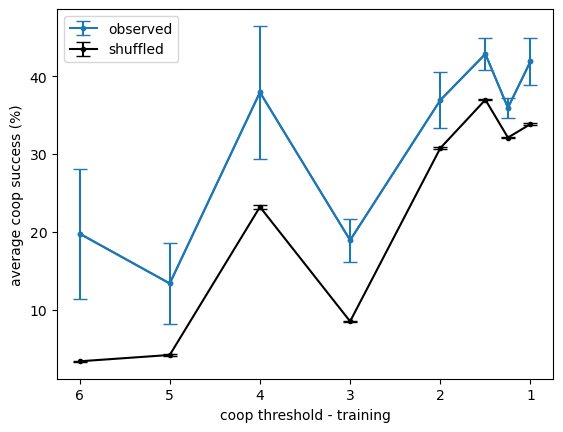

In [53]:
# NOT std actually standard error...
shuf = []
shuf_std = []
real = []
real_std = []
thresh = []
for p in pairs:
    shuf.append(np.mean(p[1]))
    shuf_std.append(np.std(p[1]) / np.sqrt(len(p[1])))

    real.append(np.mean(p[0]))
    real_std.append(np.std(p[0]) / np.sqrt(len(p[0])))

    thresh.append(p[2])
    print(p[2], np.mean(p[1]), np.std(p[1]), np.mean(p[0]), np.std(p[0]))


shuf = np.array(shuf)
shuf_std = np.array(shuf_std)

real = np.array(real)
real_std = np.array(real_std)

# plt.plot(thresh, shuf, '.', color='k')
# plt.plot(thresh, shuf, color='k')
plt.plot(thresh, real, '.', color='tab:blue')
plt.plot(thresh, real, color='tab:blue')

# plt.fill_between(thresh, shuf+(shuf_std / np.sqrt(len(shuf_std))), shuf-(shuf_std / np.sqrt(len(shuf_std))), alpha=0.2, color='k')
# plt.fill_between(thresh, real+(real_std / np.sqrt(len(real_std))), real-(real_std / np.sqrt(len(real_std))), alpha=0.2, color='tab:blue')

plt.errorbar(
    thresh, real, yerr=(real_std),
    fmt='.-', capsize=5, color='tab:blue',
    label='observed'
)

plt.errorbar(
    thresh, shuf, yerr=(shuf_std),
    fmt='.-', capsize=5, color='k',
    label='shuffled'
)


plt.xlabel('coop threshold - training')
plt.ylabel('average coop success (%)')
plt.legend()
plt.gca().invert_xaxis()


In [43]:
(shuf_std / np.sqrt(len(shuf_std))), (real_std / np.sqrt(len(real_std)))

(array([ 5.43887048,  6.25075334,  3.93697061, 10.14739548]),
 array([ 9.62531827,  7.46940845,  3.65268848, 10.21261104]))

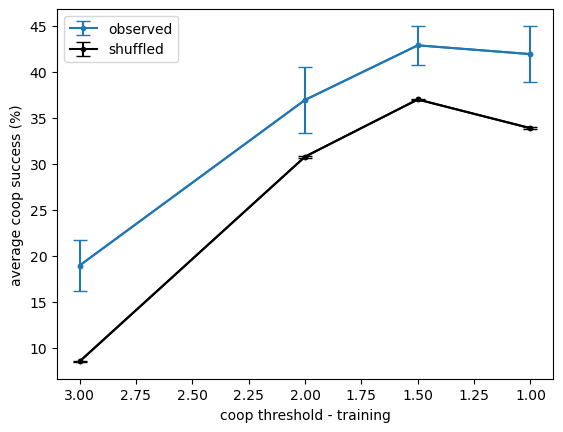

In [52]:
shuf = []
shuf_std = []
real = []
real_std = []
thresh = []

good = [3, 2, 1.5, 1]
for p in pairs:
    if p[2] in good:
        shuf.append(np.mean(p[1]))
        shuf_std.append(np.std(p[1]) / np.sqrt(len(p[1])))

        real.append(np.mean(p[0]))
        real_std.append(np.std(p[0]) / np.sqrt(len(p[0])))
        
        thresh.append(p[2])
        # print(p[2], np.mean(p[1]), np.std(p[1]), np.mean(p[0]), np.std(p[0]))

shuf = np.array(shuf)
shuf_std = np.array(shuf_std)

real = np.array(real)
real_std = np.array(real_std)

plt.plot(thresh, shuf, '.', color='k')
plt.plot(thresh, shuf, color='k')
plt.plot(thresh, real, '.', color='tab:blue')
plt.plot(thresh, real, color='tab:blue')

# plt.fill_between(thresh, shuf+shuf_std, shuf-shuf_std, alpha=0.2, color='k')
# plt.fill_between(thresh, real+real_std, real-real_std, alpha=0.2, color='tab:blue')

plt.errorbar(
    thresh, real, yerr=(real_std),
    fmt='.-', capsize=5, color='tab:blue',
    label='observed'
)

plt.errorbar(
    thresh, shuf, yerr=(shuf_std),
    fmt='.-', capsize=5, color='k',
    label='shuffled'
)


plt.xlabel('coop threshold - training')
plt.ylabel('average coop success (%)')
plt.legend()
plt.gca().invert_xaxis()


In [65]:
all_df.head(1)

,dir,session,video,color type,color pair,tracked,error,lever,mag,event id,...,coop thresh,animal id,cohort,visual,vehicle,familiar,useable,date,date sort,time
0,PairedTestingSessions,030624_KL001_TimeOut,030624_Cam1_TrNum9_Coop_KL001B-KL001Y,dyed,YB,True,0.996613,False,False,False,...,NaN,KL001B-KL001Y,KL,transparent,NaN,familiar,unuseable,30624,2024-03-06,NaN


In [68]:
# print(len(all_df[all_df['useable'] == 'normal']), len(all_df[all_df['useable'] == 'control']))
lever, mag = all_df[~all_df['lever']], all_df[~all_df['mag']]
print(len(all_df[~all_df['lever']]), len(all_df[~all_df['mag']]))

394 423


In [71]:
for dirs in np.unique(lever['dir']):
    count = (lever['dir'] == dirs).sum()
    print(dirs, count)

PairedTestingSessions 106
Training_COOPERATION 10
Training_COOP_Fiber_new 278


In [74]:
# new paired testing sessions behav files...?
# training coop fiber new
# extinction
lever[lever['dir'] == 'PairedTestingSessions'].head(50)

,dir,session,video,color type,color pair,tracked,error,lever,mag,event id,...,coop thresh,animal id,cohort,visual,vehicle,familiar,useable,date,date sort,time
0,PairedTestingSessions,030624_KL001_TimeOut,030624_Cam1_TrNum9_Coop_KL001B-KL001Y,dyed,YB,True,0.996613,False,False,False,...,NaN,KL001B-KL001Y,KL,transparent,NaN,familiar,unuseable,30624,2024-03-06,NaN
261,PairedTestingSessions,050324_KL001_TimeOut_Translucent,050324_Cam4_TrNum5_Coop_KL001B-KL001Y,dyed,YB,True,0.372370,False,False,False,...,NaN,KL001B-KL001Y,KL,translucent,NaN,familiar,unuseable,50324,2024-05-03,NaN
265,PairedTestingSessions,050324_KL001_TimeOut_Translucent,050324_Cam4_TrNum12_Coop_KL001B-KL001Y,dyed,YB,True,0.419153,False,False,False,...,NaN,KL001B-KL001Y,KL,translucent,NaN,familiar,unuseable,50324,2024-05-03,NaN
407,PairedTestingSessions,091024_FiberPho_KL008G-KL005_TimeOut,091024_Cam2_TrNum12_Coop_KL008G-KL005Y,dyed,GY,True,0.245926,False,False,False,...,NaN,KL008G-KL005Y,KL,transparent,NaN,unfamiliar,unuseable,91024,2024-09-10,NaN
409,PairedTestingSessions,091024_FiberPho_KL008G-KL005_TimeOut,091024_Cam2_TrNum8_Coop_KL008G-KL005B,dyed,GB,False,NaN,False,False,False,...,NaN,KL008G-KL005B,KL,transparent,NaN,unfamiliar,unuseable,91024,2024-09-10,NaN
411,PairedTestingSessions,091024_FiberPho_KL008G-KL005_TimeOut,091024_Cam2_TrNum10_Coop_KL008G-KL008B,dyed,GB,False,NaN,False,False,False,...,NaN,KL008B-KL008G,KL,transparent,NaN,familiar,unuseable,91024,2024-09-10,NaN
451,PairedTestingSessions,092424_FiberPho_KL005Y-KL008_TimeOut,092424_Cam2_TrNum12_Coop_KL005Y-KL008B,dyed,YB,True,0.134125,False,False,False,...,NaN,KL005Y-KL008B,KL,transparent,NaN,unfamiliar,unuseable,92424,2024-09-24,NaN
478,PairedTestingSessions,100124_FiberPho_KL004G-KL001_2X_TimeOut,100124_Cam2_TrNum15_Coop_KL004G-KL005B,dyed,GB,False,NaN,False,False,False,...,NaN,KL004G-KL005B,KL,transparent,NaN,unfamiliar,unuseable,100124,2024-10-01,NaN
484,PairedTestingSessions,100224_FiberPho_KL006G-KL008_TimeOut,100224_Cam1_TrNum8_Coop_KL006G-KL008B,dyed,GB,False,NaN,False,False,False,...,NaN,KL006G-KL008B,KL,transparent,NaN,unfamiliar,unuseable,100224,2024-10-02,NaN
497,PairedTestingSessions,101824_FiberPho_HF006G_HF001R_TimeOut,101824_Cam2_TrNum7_Coop_KL006G-KL008Y,dyed,GY,True,0.608958,False,False,False,...,NaN,KL006G-KL008Y,KL,transparent,NaN,unfamiliar,unuseable,101824,2024-10-18,NaN


## helper fns

In [44]:
# calculate the "normal" success rate from what's reported in the file
norm = calc_norm_succ(df, calc='rate')
norm_succ = calc_norm_succ(df, calc='succ')
norm_fail = calc_norm_succ(df, calc='fail')
print(np.mean(norm), np.mean(norm_succ), np.mean(norm_fail))

# and then recalcuate the "real" success rate from our definition
real = calc_real_succ(df, calc='rate')
real_succ = calc_real_succ(df, calc='succ')
real_fail = calc_real_succ(df, calc='fail')
print(np.mean(real), np.mean(real_succ), np.mean(real_fail))

# calculate the shuffled success rate 
shuf1 = calc_shuf_succ(df, calc='rate')
shuf_succ = calc_shuf_succ(df, calc='succ')
shuf_fail = calc_shuf_succ(df, calc='fail')
print(np.mean(shuf1), np.mean(shuf_succ), np.mean(shuf_fail))

52.20616536655716 31.035714285714285 36.94642857142857
52.493213674215035 31.428571428571427 36.30357142857143
46.916218370124916 24.714285714285715 28.35185185185185


In [30]:
def calc_norm_succ(df, calc='rate'):
    succ_rate = []
    
    for index, row in df.iterrows():
        dirc = row['dir'] if 'dir' in df.columns else 'PairedTestingSessions'
        lev = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{dirc}/{row['session']}/Behavioral/processed/lever/{row['video']}_lever.csv")
        trials = len(np.unique(lev['TrialNum']))
        succ = (lev.groupby('TrialNum')['coopSucc'].max().sum())
        if calc == 'rate':
            succ_rate.append(100 * succ / trials)
        elif calc == 'succ':
            succ_rate.append(succ)
        else:
            succ_rate.append(trials - succ)
    return succ_rate

In [42]:
# recaluated REAL success rate 
def calc_real_succ(df, calc='rate', thresh=1):
    # get all of the rats names
    rat_names0 = list(df['session'] + '/' + df['video'])
    rat_names1 = list(df['session'] + '/' + df['video'])
    succ_rate = []
    dirc = np.array(df['dir'])[0] if 'dir' in df.columns else 'PairedTestingSessions'

    # for every rat pair get success rate
    for i in range(len(rat_names0)):
        
        rat0 = rat_names0[i]
        rat1 = rat_names1[i]
        try:
            lev0 = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{dirc}/{rat0.split('/')[0]}/Behavioral/processed/lever/{rat0.split('/')[1]}_lever.csv")
            # lev0 = lev0[(lev0['RatID'] == 0) | (np.isnan(lev0['RatID']))]
            lev0 = lev0[(lev0['RatID'] == 0)] #  | (np.isnan(lev0['RatID']))]
            lev0_trials = np.max(lev0['TrialNum'])
            lev1 = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{dirc}/{rat1.split('/')[0]}/Behavioral/processed/lever/{rat1.split('/')[1]}_lever.csv")
            # lev1 = lev1[(lev1['RatID'] == 1)  | (np.isnan(lev1['RatID']))]
            lev1 = lev1[(lev1['RatID'] == 1)] #  | (np.isnan(lev1['RatID']))]
            lev1_trials = np.max(lev1['TrialNum'])
            trials = np.min([lev0_trials, lev1_trials])
            lev0 = lev0[lev0['TrialNum'] <= (trials)]
            lev1 = lev1[lev1['TrialNum'] <= (trials)]
        
            succ = 0
            for tri in range(1, int(trials) + 1):
                lev0_pulls = lev0[lev0['TrialNum'] == tri]
                lev1_pulls = lev1[lev1['TrialNum'] == tri]
        
                
        
                first_pull = np.min([np.min(lev0_pulls['TrialTime']), np.min(lev1_pulls['TrialTime'])])
                if (first_pull == lev0_pulls['TrialTime']).any():
                    second_pull = np.min(lev1_pulls['TrialTime'])
                else:
                    second_pull = np.min(lev0_pulls['TrialTime'])
                
                if (second_pull - first_pull) < thresh:
                    succ += 1   
                    
            if calc == 'rate':
                succ_rate.append(100 * succ / trials)
            elif calc == 'succ':
                succ_rate.append(succ)
            else:
                succ_rate.append(trials - succ)
        except Exception as e:
            print('real', e, f"{dirc}/{rat0.split('/')[0]}/Behavioral/processed/lever/{rat0.split('/')[1]}_lever.csv")
    return succ_rate

In [43]:
# shuffled by rat success rate
def calc_shuf_succ(df, calc='rate', thresh=1):
    rat_names0 = list(df['session'] + '/' + df['video'])
    rat_names1 = list(df['session'] + '/' + df['video'])
    succ_rate = []

    dirc = np.array(df['dir'])[0] if 'dir' in df.columns else 'PairedTestingSessions'
    for i in range(len(rat_names0)):
        rat0 = rat_names0[i] # random.sample(rat_names0, 1)[0]
        rat1 = random.sample(rat_names1, 1)[0]

        try:
            if rat0 == rat1:
                continue
            else:
                lev0 = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{dirc}/{rat0.split('/')[0]}/Behavioral/processed/lever/{rat0.split('/')[1]}_lever.csv")
                # lev0 = lev0[(lev0['RatID'] == 0) | (np.isnan(lev0['RatID']))]
                lev0 = lev0[(lev0['RatID'] == 0)] #  | (np.isnan(lev0['RatID']))]
                lev0_trials = np.max(lev0['TrialNum'])
                lev1 = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{dirc}/{rat1.split('/')[0]}/Behavioral/processed/lever/{rat1.split('/')[1]}_lever.csv")
                # lev1 = lev1[(lev1['RatID'] == 1)  | (np.isnan(lev1['RatID']))]
                lev1 = lev1[(lev1['RatID'] == 1)] #  | (np.isnan(lev1['RatID']))]
                lev1_trials = np.max(lev1['TrialNum'])
                trials = np.min([lev0_trials, lev1_trials])
                lev0 = lev0[lev0['TrialNum'] <= (trials)]
                lev1 = lev1[lev1['TrialNum'] <= (trials)]
            
                succ = 0
                for tri in range(1, int(trials) + 1):
                    lev0_pulls = lev0[lev0['TrialNum'] == tri]
                    lev1_pulls = lev1[lev1['TrialNum'] == tri]
            
                    first_pull = np.min([np.min(lev0_pulls['TrialTime']), np.min(lev1_pulls['TrialTime'])])
                    if (first_pull == lev0_pulls['TrialTime']).any():
                        second_pull = np.min(lev1_pulls['TrialTime'])
                    else:
                        second_pull = np.min(lev0_pulls['TrialTime'])
            
                    if (second_pull - first_pull) < thresh:
                        succ += 1    
                if calc == 'rate':
                    succ_rate.append(100 * succ / trials)
                elif calc == 'succ':
                    succ_rate.append(succ)
                else:
                    succ_rate.append(trials - succ)
        except Exception as e:
            print('shuf', e, f"{dirc}/{rat0.split('/')[0]}/Behavioral/processed/lever/{rat0.split('/')[1]}_lever.csv")
        
    return succ_rate

In [61]:
def check_ratid(df):
    get_id = []
    for index, row in df.iterrows():
        lev = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/{row['dir']}/{row['session']}/Behavioral/processed/lever/{row['video']}_lever.csv")
        if 'RatID' not in lev.columns:
            print(f"{row['dir']}/{row['session']}/Behavioral/processed/lever/{row['video']}_lever.csv")
            get_id.append(f"{row['dir']}/{row['session']}/Behavioral/processed/lever/{row['video']}_lever.csv")
        # print(len(list(lev.columns)), lev.columns)
    return get_id

## shuffle by trial not rat pair...!

In [10]:
# shuffled by trial success rate
rat_names0 = list(df['session'] + '/' + df['vid'])
first_pulls = []
for i in range(len(rat_names0)):
    rat = rat_names0[i]
    lev = pd.read_csv(f"/gpfs/radev/pi/saxena/aj764/PairedTestingSessions/{rat.split('/')[0]}/Behavioral/processed/lever/{rat.split('/')[1]}_lever.csv")
    lev0 = lev0[(lev0['RatID'] == 0)]
    lev1 = lev1[(lev1['RatID'] == 0)]
    min_times0 = lev0.groupby('TrialNum')['TrialTime'].min().reset_index()
    min_times1 = lev1.groupby('TrialNum')['TrialTime'].min().reset_index()
    first_pulls = np.concat(([first_pulls, np.array(min_times0['TrialTime']), np.array(min_times1['TrialTime'])]))

NameError: name 'lev0' is not defined

In [241]:
first_pulls = list(first_pulls)
trials = len(first_pulls) // 2

In [242]:
succ = 0
for i in range(len(first_pulls) // 2):
    rat0 = random.choice(first_pulls)
    first_pulls.remove(rat0)
    rat1 = random.choice(first_pulls)
    first_pulls.remove(rat1)
    
    if np.abs(rat0 - rat1) < 1:
        succ += 1

In [247]:
succ / trials

0.5859788359788359

In [ ]:
# could do this across session by creating a differnet DF for each "step" of training cooepration --> read as cooperation threshold...
# see how many sessions we would have each cooperation threshold anyways...! 